# Task 1: Heart Disease Prediction with a Feed-Forward Neural Network

A feed-forward neural network (MLP) is trained on the Cleveland heart disease dataset to predict whether a patient has heart disease.

# Declaration of AI Usage

This research notebook was developed with the assistance of generative artificial intelligence (AI) tools as a supplementary aid. AI was used for the following purposes:

* Studying and understanding the concepts, algorithms, and models relevant to this research.
* Assisting with code development, debugging, and improving the overall implementation.
* Enhancing the presentation of the notebook, including improving figures, visualizations, and refining the wording of comments and markdown sections to make them clearer and more suitable for a research notebook.

All AI-generated suggestions were carefully reviewed, verified, and modified where necessary before being incorporated into the final notebook. The authors take full responsibility for the methodology, implementation, results, analysis, and conclusions presented in this work.


## 1. Imports and Reproducibility Setup

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score, log_loss)

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)

os.makedirs("figures", exist_ok=True)

## 2. Loading the Dataset

In [2]:
df = pd.read_csv("/content/sample_data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


## 3. Cleaning the Data

In [3]:
df = df[df["thal"].isin(["normal", "fixed", "reversible"])].reset_index(drop=True)
print(f"{len(df)} rows remain after removing corrupted 'thal' entries")

301 rows remain after removing corrupted 'thal' entries


## 4. Defining Feature Groups

Features are split into three groups that are treated differently during preprocessing:
- **Continuous** features, which will be standardised
- **Categorical** features with more than two levels, which will be one-hot encoded
- **Binary** features, which are already coded as 0/1 and are left untouched

In [4]:
NUM_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak"]   # continuous
CAT_COLS = ["cp", "restecg", "slope", "ca", "thal"]            # categorical (>2 levels)
BIN_COLS = ["sex", "fbs", "exang"]                             # already binary 0/1

## 5. Preprocessing: One-Hot Encoding

The integer codes of e.g. `cp` (chest pain type) are nominal, not ordinal, so feeding them as raw numbers would impose a false ordering on the network. They are therefore one-hot encoded.

In [5]:
X = pd.get_dummies(df[NUM_COLS + BIN_COLS + CAT_COLS], columns=CAT_COLS)
y = df["target"].values.astype("float32")
X = X.values.astype("float32")
print(f"{len(y)} samples, {X.shape[1]} features after one-hot encoding, "
      f"{int(y.sum())} positive (heart disease)")

301 samples, 26 features after one-hot encoding, 83 positive (heart disease)


## 6. Train / Validation / Test Split

A stratified 64/16/20 % split into train / validation / test. Stratification keeps the class ratio (~27 % positives) equal in all splits.

In [6]:
X_tmp, X_te, y_tmp, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_tmp, y_tmp, test_size=0.20, stratify=y_tmp, random_state=SEED)

print(f"train: {X_tr.shape[0]}, val: {X_va.shape[0]}, test: {X_te.shape[0]}")

train: 192, val: 48, test: 61


## 7. Feature Scaling

Standardise the continuous features (zero mean, unit variance). The scaler is fitted on the training set only to avoid information leakage from validation/test data. One-hot columns are left unchanged.

In [7]:
scaler = StandardScaler().fit(X_tr[:, :len(NUM_COLS)])
for A in (X_tr, X_va, X_te):
    A[:, :len(NUM_COLS)] = scaler.transform(A[:, :len(NUM_COLS)])

## 8. Model Definition

A small fully connected network for binary classification. `l2` weight decay is used as regularisation against overfitting, which is important because the dataset is small.

In [8]:
def build_model(hidden=(32, 16), lr=1e-3, l2=1e-3):
    model = keras.Sequential([layers.Input(shape=(X_tr.shape[1],))])
    for h in hidden:
        model.add(layers.Dense(h, activation="relu",
                               kernel_regularizer=regularizers.l2(l2)))

    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

## 9. Training Function with Early Stopping

Training uses early stopping on the validation loss. The weights of the epoch with the lowest validation loss are restored, which acts as implicit regularisation.

In [9]:
def train(model, epochs=300, patience=30, verbose=0):

    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                       restore_best_weights=True)
    hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                     epochs=epochs, batch_size=32, callbacks=[es],
                     verbose=verbose)
    return dict(hist.history)

## 10. Training the Baseline Model

In [10]:
model = build_model()
hist = train(model)
best_ep = int(np.argmin(hist["val_loss"])) + 1
print(f"best validation loss {min(hist['val_loss']):.3f} at epoch {best_ep}")

best validation loss 0.323 at epoch 39


## 11. Visualizing Training and Validation Curves

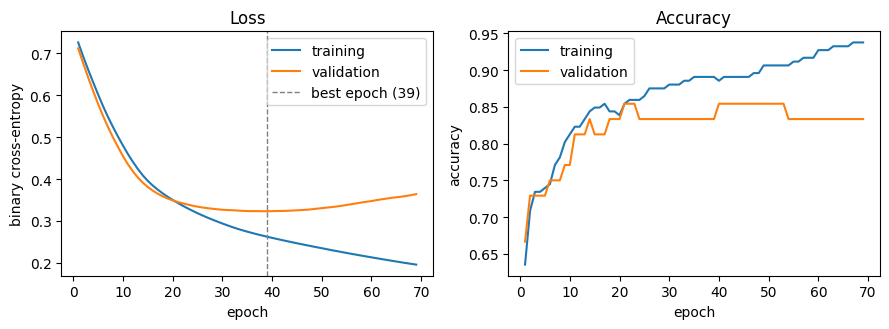

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ep = np.arange(1, len(hist["loss"]) + 1)
ax[0].plot(ep, hist["loss"], label="training")
ax[0].plot(ep, hist["val_loss"], label="validation")
ax[0].axvline(best_ep, ls="--", c="grey", lw=1, label=f"best epoch ({best_ep})")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("binary cross-entropy")
ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(ep, hist["accuracy"], label="training")
ax[1].plot(ep, hist["val_accuracy"], label="validation")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
ax[1].set_title("Accuracy"); ax[1].legend()
fig.tight_layout(); fig.savefig("figures/fig_train_curves.pdf")
plt.show()

## 12. Evaluation on the Test Set

The model's predicted probabilities are thresholded at 0.5 to obtain class predictions, and standard classification metrics are reported.

In [12]:
from sklearn.metrics import log_loss

p_te = model.predict(X_te, verbose=0).ravel()      # predicted probabilities
y_hat = (p_te > 0.5).astype(int)                   # default decision threshold

test_ce = log_loss(y_te, p_te)

print("Test accuracy      :", round(accuracy_score(y_te, y_hat), 3))
print("Test cross-entropy :", round(test_ce, 3))
print("Test ROC-AUC       :", round(roc_auc_score(y_te, p_te), 3))
print("Precision          :", round(precision_score(y_te, y_hat), 3))
print("Recall             :", round(recall_score(y_te, y_hat), 3))
print("F1 score           :", round(f1_score(y_te, y_hat), 3))
cm = confusion_matrix(y_te, y_hat)
print("Confusion matrix:\n", cm)

Test accuracy      : 0.836
Test cross-entropy : 0.382
Test ROC-AUC       : 0.908
Precision          : 0.769
Recall             : 0.588
F1 score           : 0.667
Confusion matrix:
 [[41  3]
 [ 7 10]]


## 13. Adjusting the Decision Threshold

Because the classes are imbalanced (27 % positives) and false negatives are clinically more harmful than false positives, the metrics for a lowered decision threshold are also reported.

In [13]:
for thr in (0.3,):
    yh = (p_te > thr).astype(int)
    print(f"threshold {thr}: acc {accuracy_score(y_te, yh):.3f}, "
          f"precision {precision_score(y_te, yh):.3f}, "
          f"recall {recall_score(y_te, yh):.3f}, "
          f"f1 {f1_score(y_te, yh):.3f}")

threshold 0.3: acc 0.885, precision 0.812, recall 0.765, f1 0.788


## 14. ROC Curve and Confusion Matrix

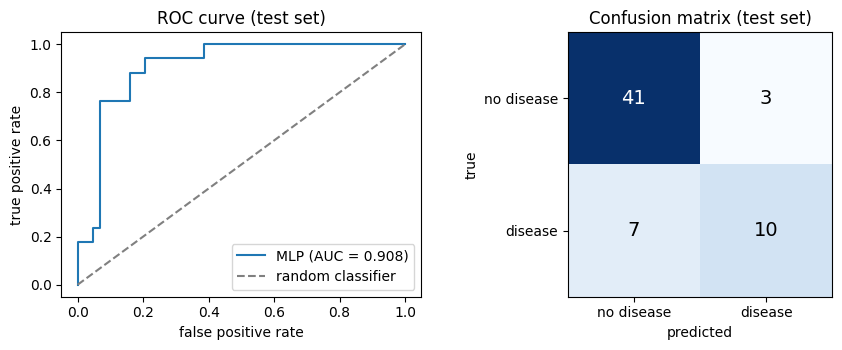

In [14]:
fpr, tpr, _ = roc_curve(y_te, p_te)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
ax[0].plot(fpr, tpr, label=f"MLP (AUC = {roc_auc_score(y_te, p_te):.3f})")
ax[0].plot([0, 1], [0, 1], "--", c="grey", label="random classifier")
ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate")
ax[0].set_title("ROC curve (test set)"); ax[0].legend()
ax[1].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax[1].text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                   color="white" if cm[i, j] > cm.max() / 2 else "black")
ax[1].set_xticks([0, 1], ["no disease", "disease"])
ax[1].set_yticks([0, 1], ["no disease", "disease"])
ax[1].set_xlabel("predicted"); ax[1].set_ylabel("true")
ax[1].set_title("Confusion matrix (test set)")
fig.tight_layout(); fig.savefig("figures/fig_roc_cm.pdf")
plt.show()

## 15. Hyperparameter Study:

Both learning rate and network size effects are investigated using the validation set. The model is trained with different configurations, and performance is compared at the best epoch (determined by validation loss).

Running learning rate study...
  Training with lr=0.0001... ✓ Best val loss: 0.338
  Training with lr=0.001... ✓ Best val loss: 0.346
  Training with lr=0.01... ✓ Best val loss: 0.351
  Training with lr=0.1... ✓ Best val loss: 0.364

Running network size study...
  [1/5] Training architecture 8... ✓ Best val acc: 0.896
  [2/5] Training architecture 32... ✓ Best val acc: 0.854
  [3/5] Training architecture 32-16... ✓ Best val acc: 0.833
  [4/5] Training architecture 64-32... ✓ Best val acc: 0.812
  [5/5] Training architecture 128-64-32... ✓ Best val acc: 0.854

Architecture sweep (val acc at best epoch): {'8': np.float64(0.896), '32': np.float64(0.854), '32-16': np.float64(0.833), '64-32': np.float64(0.812), '128-64-32': np.float64(0.854)}


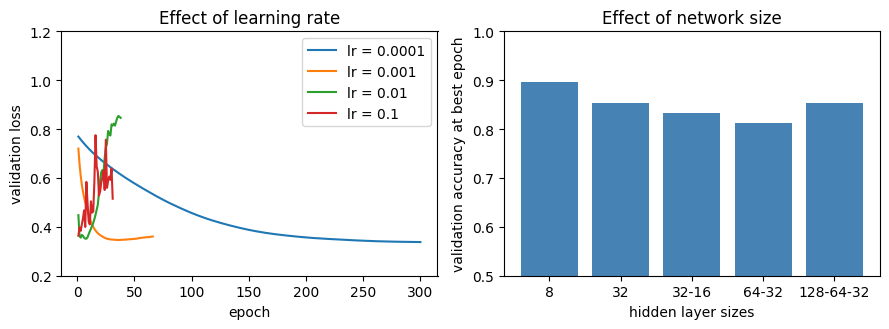

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))

# ============ Learning Rate Effect ============
print("Running learning rate study...")
for lr in [1e-4, 1e-3, 1e-2, 1e-1]:
    print(f"  Training with lr={lr}...", end=" ")
    h = train(build_model(lr=lr))
    ax[0].plot(np.arange(1, len(h["val_loss"]) + 1), h["val_loss"],
               label=f"lr = {lr:g}")
    print(f"✓ Best val loss: {min(h['val_loss']):.3f}")

ax[0].set_xlabel("epoch")
ax[0].set_ylabel("validation loss")
ax[0].set_ylim(0.2, 1.2)
ax[0].legend()
ax[0].set_title("Effect of learning rate")

# ============ Network Size Effect ============
print("\nRunning network size study...")
archs = [(8,), (32,), (32, 16), (64, 32), (128, 64, 32)]
accs = []

for i, a in enumerate(archs, 1):
    arch_str = "-".join(map(str, a))
    print(f"  [{i}/5] Training architecture {arch_str}...", end=" ")
    h = train(build_model(hidden=a))
    best_idx = int(np.argmin(h["val_loss"]))
    accs.append(h["val_accuracy"][best_idx])
    print(f"✓ Best val acc: {accs[-1]:.3f}")

labels = ["-".join(map(str, a)) for a in archs]
results = dict(zip(labels, np.round(accs, 3)))
print("\nArchitecture sweep (val acc at best epoch):", results)

ax[1].bar(labels, accs, color="steelblue")
ax[1].set_ylim(0.5, 1.0)
ax[1].set_xlabel("hidden layer sizes")
ax[1].set_ylabel("validation accuracy at best epoch")
ax[1].set_title("Effect of network size")

fig.tight_layout()
fig.savefig("figures/fig_hyperparams.pdf")
plt.show()
